# Integrative Industry Synthesis Project: Modeling the German Energy Market
## by <i>Andreas Grotz</i>





## Table of Contents
- [Introduction](#intro)
- [Loading the Modules](#mod)
- [Importing and Preparing the Data](#data)
- [Predicting the Energy Price](#price)
- [Predicting the Residual Load](#residual)
- [Forecasting the Total Load](#total)
- [Workflows and Use Cases](#flows)
- [Limitations and Future Improvements](#lim)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

The German energy market has two notable features, which are e.g. explained in some detail here: https://www.smard.de/page/en/wiki-article/5884/5840/this-is-how-the-electricity-market-works. First, the country tries to transition to renewable energy sources, which as of 2025 contribute more than 50% of the total energy supply on average. However, they are subject to availabiliy of the respective source (sunshine and wind, for example). The gap between the renewables' supply and the energy demand needs to be filled by conventional energy sources. Since Germany has decided to switch off its nuclear power plants, these conventional sources are mainly coal and natural gas. The second feature is the so-called merit order system for determining the daily wholesale energy price. Lower-cost suppliers have priority, and the supplier with the highest marginal cost, that gets to contribute to the total supply in order to match the demand, sets the price for the whole system. These last marginal contributors tend to be the relatively expensive coal and natural gas power plants.

The aim of this project is to develop data-driven models and workflows for the German energy market. We start by loading and cleaning several datasets:
- From the regulator for the German energy market, we obtained time series for the total load (i.e. the total energy demand on a given day) and the residual load (i.e. the fraction of the energy supply coming from conventional sources on that day), as well as a time series for daily wholesale energy prices.
- From the German Meteorological Service, we obtained time series for variables driving the supply of renewable energies, namely wind speed, sunshine hours, and temperatures.
- From Yahoo Finance, we obtained time series for daily prices of the commodities natural gas and European carbon allowances, which drive the marginal cost of natural gas power plants.

We will use these datasets in order to develop three building block models:
- Our first model is intended to predict the daily wholesale energy price, given the total load, the residual load, and the commodity prices on each day.
- Our second model is intended to predict the daily residual load, given the total load and the meteorological variables on each day.
- Our third model is intended to forecast the total load for a given day, given the timeseries of total loads and temperatures up to that day.

The building block models are then integrated into a system of several work flows and potential use cases in the German energy market.

We also list some limitations and potential improvements of our system, and conclude with a short summary.


<a id='mod'></a>
### Loading the Modules

In this section, we import required Python modules.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip install scipy
#!pip install statsmodels
#!pip install scikit-learn
#!pip install yfinance 
#!pip3 install torch torchvision
#!pip3 install torcheval

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torcheval.metrics import R2Score
import yfinance as yf

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# We set a fixed seed of the random generator for better reprodicibility, see
# https://docs.pytorch.org/docs/stable/notes/randomness.html#reproducibility
torch.manual_seed(0);

<a id='data'></a>
### Importing and Preparing the Data

In this section, we import four different datasets required for our modeling, and we perform several cleaning tasks.

The <b>first dataset</b> that we import was downloaded from the regulator for the German energy market (https://www.smard.de/home/downloadcenter/download-marktdaten/):

In [5]:
df_consumption = pd.read_csv('Realisierter_Stromverbrauch_201501010000_202412310000_Tag.csv', sep=";", thousands=".", decimal=','
                            , parse_dates=["Datum von", "Datum bis"], date_format='%d.%m.%Y')

In [6]:
df_consumption.head()

,Datum von,Datum bis,Netzlast [MWh] Berechnete Auflösungen,Netzlast inkl. Pumpspeicher [MWh] Berechnete Auflösungen,Pumpspeicher [MWh] Berechnete Auflösungen,Residuallast [MWh] Berechnete Auflösungen
0,2015-01-01,2015-01-02,1106343.98,1133468.30,27124.32,761712.01
1,2015-01-02,2015-01-03,1299202.20,1334453.56,35251.37,691721.64
2,2015-01-03,2015-01-04,1223466.05,1258747.92,35281.87,745091.11
3,2015-01-04,2015-01-05,1177896.00,1202337.75,24441.75,767345.50
4,2015-01-05,2015-01-06,1425927.50,1451660.75,25733.25,1172036.25


It contains daily values for the total network load in the grid ("Netzlast") denoted in MegaWatt hours (MWh), as well as the residual load ("Residuallast") that has been generated by conventional power plants (natural gas, coal, nuclear, etc.) as opposed to renewable energies. We only require these two columns as well as the date label. Hence we remove the other columns, and use English column headers:

In [7]:
df_consumption.drop(['Datum bis', 'Netzlast [MWh] Berechnete Auflösungen', 'Pumpspeicher [MWh] Berechnete Auflösungen'], axis=1, inplace=True)
df_consumption.columns = ['Date', 'Total_Load', 'Residual_Load']

Next, we translate the residual load into a percentage of the total load. Percentages are constrainted between zero and one, which is not ideal for artificial intelligence methods. We therefore transform the percentage number to an unconstrained variable by using the cumulative normal probability function. 

In [8]:
df_consumption['Residual_Fraction'] = df_consumption['Residual_Load'] / df_consumption['Total_Load']
df_consumption.drop(['Residual_Load'], axis=1, inplace=True)

In [9]:
df_consumption['Residual_Fraction_Probit'] = df_consumption['Residual_Fraction'].apply(stats.norm.ppf)

In [10]:
df_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      3653 non-null   datetime64[ns]
 1   Total_Load                3653 non-null   float64       
 2   Residual_Fraction         3653 non-null   float64       
 3   Residual_Fraction_Probit  3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 114.3 KB


There are no missing values in these data. In addition, the time series plots below show that there is a strong seasonal pattern in the data (higher power consumption in winter than in summer). There is also a slightly decreasing trend in the residual load, probably due to installation of more renewable energy sources. 

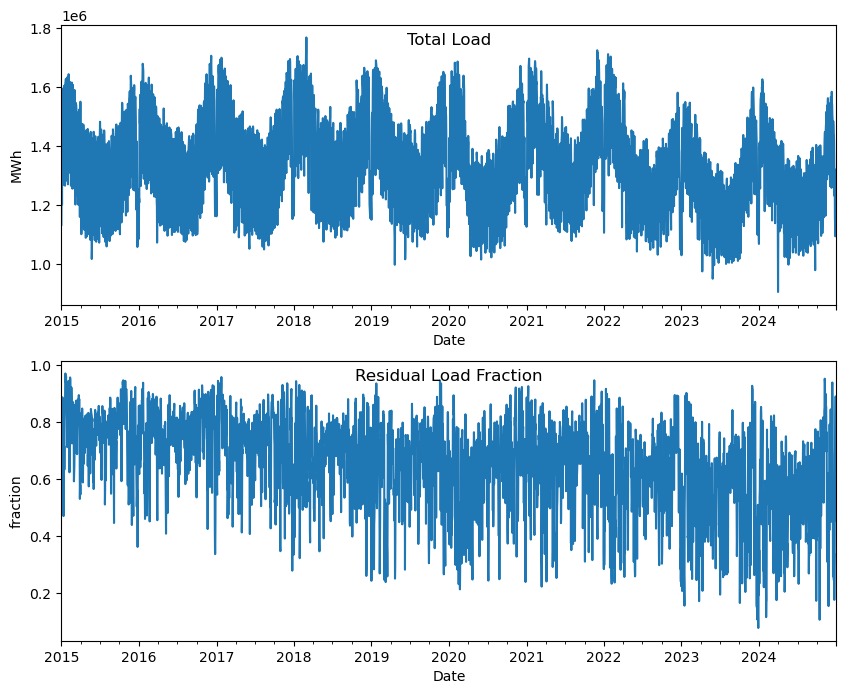

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
df_consumption.plot(x='Date', y='Total_Load', ax=ax[0]);
df_consumption.plot(x='Date', y='Residual_Fraction', ax=ax[1]);
ax[0].set(ylabel='MWh')
ax[0].set_title('Total Load', y=1.0, pad=-14)
ax[1].set(ylabel='fraction')
ax[1].set_title('Residual Load Fraction', y=1.0, pad=-14)
ax[0].get_legend().remove()
ax[1].get_legend().remove()
plt.show()

Our <b>second dataset</b> is also sourced from the German regulator, using the same URL as for the first set. It contains daily values for wholesale power prices per MWh:

In [12]:
df_energyprices = pd.read_csv('Gro_handelspreise_201501010000_202412310000_Tag.csv', sep=";", decimal=','
                            , parse_dates=["Datum von", "Datum bis"], date_format='%d.%m.%Y', na_values='-')

In [13]:
df_energyprices.head()

,Datum von,Datum bis,Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen,∅ Anrainer DE/LU [€/MWh] Berechnete Auflösungen,Belgien [€/MWh] Berechnete Auflösungen,Dänemark 1 [€/MWh] Berechnete Auflösungen,Dänemark 2 [€/MWh] Berechnete Auflösungen,Frankreich [€/MWh] Berechnete Auflösungen,Niederlande [€/MWh] Berechnete Auflösungen,Norwegen 2 [€/MWh] Berechnete Auflösungen,Österreich [€/MWh] Berechnete Auflösungen,Polen [€/MWh] Berechnete Auflösungen,Schweden 4 [€/MWh] Berechnete Auflösungen,Schweiz [€/MWh] Berechnete Auflösungen,Tschechien [€/MWh] Berechnete Auflösungen,DE/AT/LU [€/MWh] Berechnete Auflösungen,Italien (Nord) [€/MWh] Berechnete Auflösungen,Slowenien [€/MWh] Berechnete Auflösungen,Ungarn [€/MWh] Berechnete Auflösungen
0,2015-01-01,2015-01-02,NaN,NaN,NaN,16.31,18.20,NaN,NaN,27.23,NaN,NaN,24.91,36.63,21.70,NaN,NaN,30.31,33.09
1,2015-01-02,2015-01-03,NaN,NaN,NaN,4.97,11.62,NaN,NaN,27.55,NaN,NaN,24.99,41.61,12.25,NaN,NaN,45.18,43.78
2,2015-01-03,2015-01-04,NaN,NaN,NaN,15.29,15.50,NaN,NaN,27.18,NaN,NaN,24.06,36.59,18.10,NaN,NaN,43.98,38.32
3,2015-01-04,2015-01-05,NaN,NaN,NaN,21.06,21.55,NaN,NaN,28.08,NaN,NaN,28.25,31.72,12.83,NaN,NaN,38.21,40.36
4,2015-01-05,2015-01-06,NaN,NaN,44.83,38.00,38.41,44.43,41.71,34.93,NaN,NaN,38.45,47.39,38.55,35.86,52.58,42.69,44.70


There are columns for several European energy market regions, of which only two are relevant for the German market. Hence we drop the other columns and we use English column headers:

In [14]:
cols_to_drop = [c for c in df_energyprices.columns if c not in ['Datum von', 'Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen', 'DE/AT/LU [€/MWh] Berechnete Auflösungen']]
df_energyprices.drop(cols_to_drop, axis=1, inplace=True)
df_energyprices.columns = ['Date', 'DE/LU', 'DE/AT/LU']

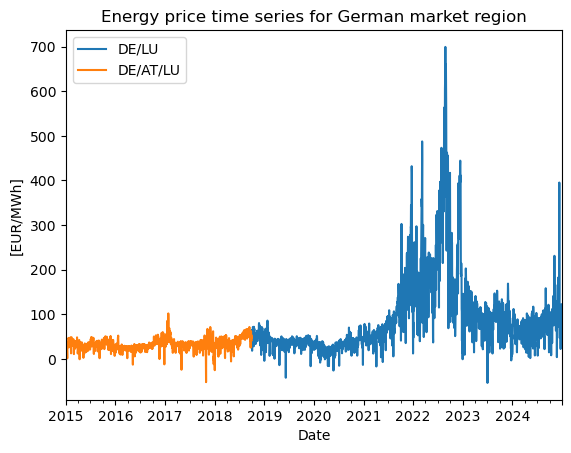

In [15]:
df_energyprices.plot(x='Date');
plt.title('Energy price time series for German market region')
plt.xlabel('Date')
plt.ylabel('[EUR/MWh]')
plt.show()

As one can see in the above plot, there seems to have been a switch of market region cuts in 2018. Germany (DE) moved from a common region with Austria (AT) and Luxemburg (LU), to a common region with Luxemburg only. Indeed, the two columns have no overlapping values:

In [16]:
df_energyprices[df_energyprices['DE/AT/LU'].notna() & df_energyprices['DE/LU'].notna()]

,Date,DE/LU,DE/AT/LU


We therefore merge the two columns into a single column with power prices for the German market:

In [17]:
def get_notna_price(row):
    if not np.isnan(row['DE/LU']):
        return row['DE/LU']
    else:
        return row['DE/AT/LU']

In [18]:
df_energyprices['Power_Price'] = df_energyprices.apply(get_notna_price, axis=1)

In [19]:
df_energyprices.drop(['DE/LU', 'DE/AT/LU'], axis=1, inplace=True)
df_energyprices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3653 non-null   datetime64[ns]
 1   Power_Price  3649 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


There are only four missing values at the begin of the 2015-2024 time series, which we drop from the frame:

In [20]:
df_energyprices.dropna(axis=0, inplace=True)
df_energyprices.head()

,Date,Power_Price
4,2015-01-05,35.86
5,2015-01-06,33.88
6,2015-01-07,38.72
7,2015-01-08,28.48
8,2015-01-09,24.25


The <b>third dataset</b> was obtained from the German Meteorological Service (https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/tageswerte_KL_01691_18580101_20241231_hist.zip). It contains daily meteorological data for the city of Goettingen, which is close to the geographical center of Germany. Note that we have already removed a lot of whitespaces in the raw file via find and replace in a text editor, so we can import it smoothly here.

In [21]:
df_weather = pd.read_csv('produkt_klima_tag_18580101_20241231_01691.txt', sep=";", parse_dates=["MESS_DATUM"], date_format='%Y%m%d')

In [22]:
df_weather.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,1691,1858-01-01,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,-999.0,1017.2,1.5,96.0,-999.0,-999.0,-999.0,eor
1,1691,1858-01-02,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,5.7,1016.5,-0.7,96.0,-999.0,-999.0,-999.0,eor
2,1691,1858-01-03,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,-999.0,1018.9,-1.1,92.0,-999.0,-999.0,-999.0,eor
3,1691,1858-01-04,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,2.7,1018.6,-9.5,89.0,-999.0,-999.0,-999.0,eor
4,1691,1858-01-05,-999,-999.0,-999.0,1,0.0,0,-999.0,-999,-999.0,2.4,1012.4,-7.6,77.0,-999.0,-999.0,-999.0,eor


The file contains several columns, which are described in detail in a manual (https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/DESCRIPTION_obsgermany-climate-daily-kl_en.pdf). We keep the columns for mean wind speed, hours of sunshine, and mean temperature, along with the date column. We again rename using English column headers:

In [23]:
cols_to_drop = [c for c in df_weather.columns if c not in ['MESS_DATUM', 'FM', 'SDK', 'TMK']]
df_weather.drop(cols_to_drop, axis=1, inplace=True)
df_weather.columns = ['Date', 'Wind_Speed', 'Sunshine_Hours', 'Temperature']

The file encodes NA values with the float value -999.0, so we need to clean it accordingly. Moreover, we can restrict to the 2015-2024 period:

In [24]:
df_weather = df_weather[(df_weather.Date >= '2015-01-01') & (df_weather.Date <= '2024-12-31')]
df_weather.replace(float(-999.0),np.nan, inplace=True)
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3653 entries, 55672 to 59324
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            3653 non-null   datetime64[ns]
 1   Wind_Speed      3615 non-null   float64       
 2   Sunshine_Hours  3653 non-null   float64       
 3   Temperature     3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 142.7 KB


There is a small number of 38 missing values for wind speed. In order to keep a daily series, we impute with the mean value rather than dropping these rows. Mean is the most straighforward method, and the impact should be limited given the small number of NAs. 

In [25]:
df_weather["Wind_Speed"] = df_weather["Wind_Speed"].fillna(df_weather["Wind_Speed"].mean())

As one would expect, there are clear seasonality pattern in the meteorological variables:

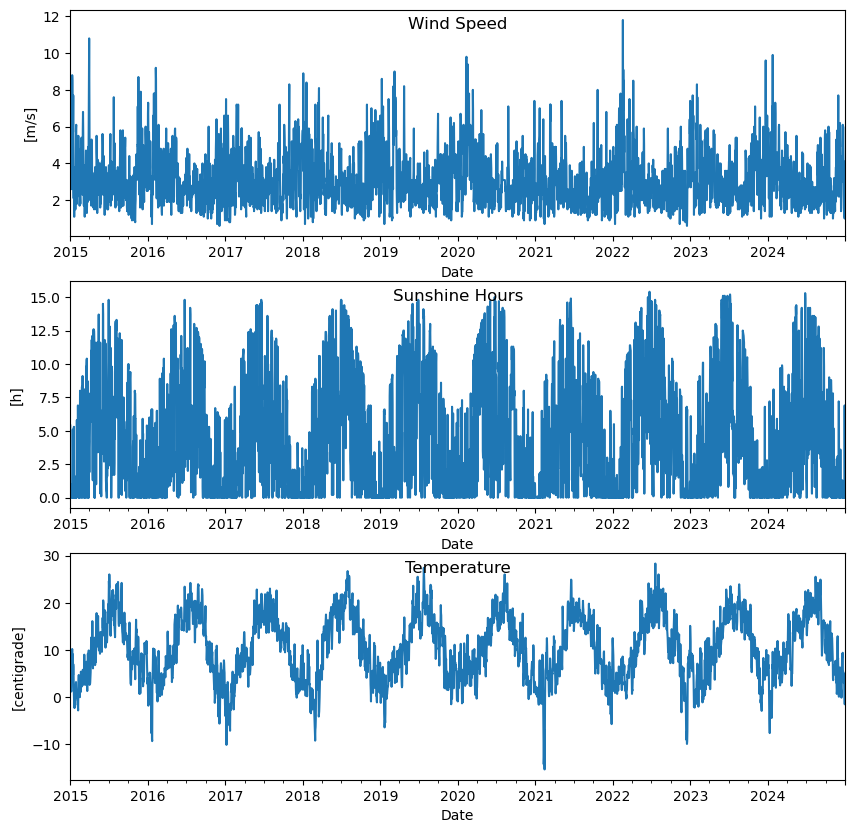

In [26]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
df_weather.plot(x='Date', y='Wind_Speed', ax=ax[0]);
df_weather.plot(x='Date', y='Sunshine_Hours', ax=ax[1]);
df_weather.plot(x='Date', y='Temperature', ax=ax[2]);
ax[0].set(ylabel='[m/s]')
ax[0].set_title('Wind Speed', y=1.0, pad=-14)
ax[1].set(ylabel='[h]')
ax[1].set_title('Sunshine Hours', y=1.0, pad=-14)
ax[2].set(ylabel='[centigrade]')
ax[2].set_title('Temperature', y=1.0, pad=-14)
ax[0].get_legend().remove()
ax[1].get_legend().remove()
ax[2].get_legend().remove()
plt.show()

The <b>fourth dataset</b> we consider are daily prices for commodities used in conventional power plants. The main resources for conventional energy in Germany are natural gas and coal. 
- For coal prices, a reasonable datasource would be the front contract price of the API2 future traded on the Intercontinental Exchange (see https://www.ice.com/products/243/API2-Rotterdam-Coal-Futures). Unfortunately, we haven't found any open-source data for for that future.
- For natural gas, we can use the level of the TTF future traded on the ICE (see https://www.ice.com/products/27996665/Dutch-TTF-Natural-Gas-Futures), which are representative for wholesale prices of natural gas in Europe.
- In addition, conventional power plants have to purchase certificates for carbon emission allowance. We haven't found any open source data for the spot or futures market (https://www.eex.com/en/markets/environmental-markets/eu-ets-spot-futures-options), but there is a Solactive index available that we can use (https://www.solactive.com/index/DE000SL0E4X3/).

We obtain the time series for natural gas and carbon allowances via the Yahoo Finance API:

In [27]:
# Note: The timeseries has already been downloaded and are stored in the ttf.csv file in this project.
# By setting the below variable to True, it can be reloaded from Yahoo Finance
reload_data_imports = False
if(reload_data_imports):
    df_natgasprices = yf.download(tickers=["TTF=F"], start='2015-01-01', end='2024-12-31')
    df_natgasprices.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
    df_natgasprices.columns = ['Gas_Price']
    df_carbonprices = yf.download(tickers=["DE000SL0E4X3.SG"], start='2015-01-01', end='2024-12-31')
    df_carbonprices.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
    df_carbonprices.columns = ['Carbon_Price']
    df_commodityprices = df_natgasprices.join(df_carbonprices, on='Date', how='inner')
    df_commodityprices.to_csv('commodity_prices.csv')

In [28]:
df_commodityprices = pd.read_csv("commodity_prices.csv")
df_commodityprices.Date = pd.to_datetime(df_commodityprices.Date)
df_commodityprices.set_index('Date', inplace=True)
df_commodityprices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1729 entries, 2018-01-05 to 2024-12-30
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gas_Price     1729 non-null   float64
 1   Carbon_Price  1729 non-null   float64
dtypes: float64(2)
memory usage: 40.5 KB


Unfortunately, the time series available for the TTF future and the carbon index on Yahoo Finance do not cover the full period 2015-2024, but only for 2018-2024. In addition, it only contains values on trading days, while we have power prices available for each calendar day. This will likely have a negative impact when using them in our energy price model. Also, the plots below show that the price distributions are not homogeneous, but there are two or three different regimes in the data. 

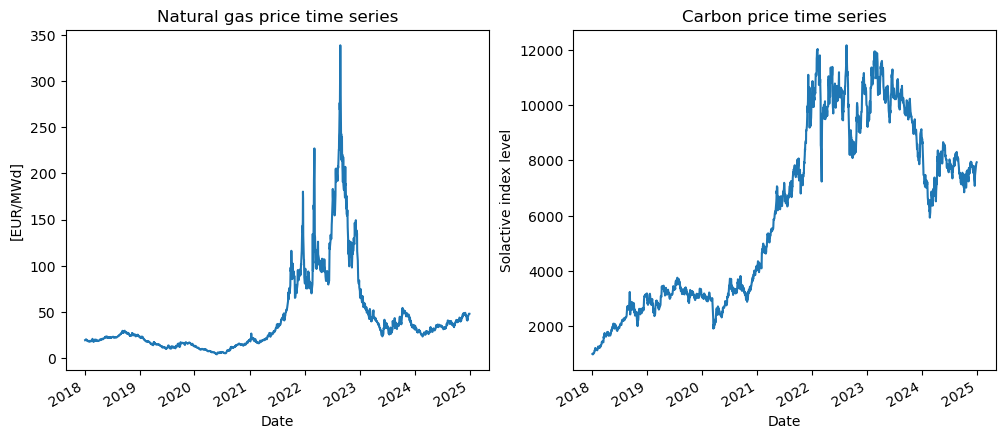

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df_commodityprices.plot(y='Gas_Price', ax=ax[0]);
df_commodityprices.plot(y='Carbon_Price', ax=ax[1]);
ax[0].set(ylabel='[EUR/MWd]')
ax[0].set_title('Natural gas price time series')
ax[1].set(ylabel='Solactive index level')
ax[1].set_title('Carbon price time series')
ax[0].get_legend().remove()
ax[1].get_legend().remove()
plt.show()

<a id='price'></a>
### Predicting the Energy Price

Our first task is to predict the power price from independent variables. Our hypothesis is that this is driven by the commodity prices, the total energy demand, and the fraction of power generated by conventional plants. We start by preparing a specific dataframe:

In [30]:
df_pricing = df_energyprices.copy()

In [31]:
df_pricing = df_pricing.join(df_commodityprices, on='Date', how='inner')

In [32]:
df_pricing = df_pricing.join(df_consumption[['Date','Total_Load','Residual_Fraction_Probit']].set_index('Date'), on='Date', how='inner').set_index('Date')

In [33]:
df_pricing.dropna(axis=0, inplace=True)
df_pricing.head()

,Power_Price,Gas_Price,Carbon_Price,Total_Load,Residual_Fraction_Probit
Date,,,,,
2018-01-05,31.51,18.915001,1000.000000,1552185.50,0.280172
2018-01-08,30.50,19.049999,984.580017,1624088.25,0.319437
2018-01-09,30.26,19.434999,1000.000000,1661009.00,0.352946
2018-01-10,41.33,19.325001,1014.140015,1596641.00,1.064197
2018-01-11,47.73,19.320000,1005.140015,1593910.75,1.588141


The carbon price and the total load are larger by several orders of magnitude than the other variables. We therefore rescale them in order to ensure a more stable model estimation.

In [34]:
df_pricing['Total_Load'] = df_pricing['Total_Load'] / 1e6
df_pricing['Carbon_Price'] = df_pricing['Carbon_Price'] / 1e3

In [35]:
df_pricing.corr()

,Power_Price,Gas_Price,Carbon_Price,Total_Load,Residual_Fraction_Probit
Power_Price,1.000000,0.922289,0.624541,-0.121606,0.196499
Gas_Price,0.922289,1.000000,0.626315,-0.111667,-0.009158
Carbon_Price,0.624541,0.626315,1.000000,-0.326742,-0.214617
Total_Load,-0.121606,-0.111667,-0.326742,1.000000,0.089016
Residual_Fraction_Probit,0.196499,-0.009158,-0.214617,0.089016,1.000000


Looking at the correlation matrix, there is indeed a strong relationship between the power price and the explanatory variables. We validate this by running statistical tests for the correlation, which we already used in the second capstone project:

In [36]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Gas_Price'], alternative='two-sided')

PearsonRResult(statistic=np.float64(0.9222885917670883), pvalue=np.float64(0.0))

In [37]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Carbon_Price'], alternative='two-sided')

PearsonRResult(statistic=np.float64(0.6245405296192119), pvalue=np.float64(1.2255023238162546e-187))

In [38]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Residual_Fraction_Probit'], alternative='two-sided')

PearsonRResult(statistic=np.float64(0.19649850798590077), pvalue=np.float64(1.6481017200436022e-16))

In [39]:
stats.pearsonr(df_pricing['Power_Price'], df_pricing['Total_Load'], alternative='two-sided')

PearsonRResult(statistic=np.float64(-0.121605687953664), pvalue=np.float64(3.9429518329152494e-07))

The tests show that we can accept the alternative hypothesis of non-zero correlation between power price and explanatory variables at e.g. the 99% level. This suggests that a linear regression model could be a good choice for the prediction. So let us split the data into a train and test set, and let us fit a linear regression model using the same packages as in the Statistics for Data Analysis nanodegree:

In [40]:
cols = [c for c in df_pricing.columns if c != 'Power_Price']
X_pr_train, X_pr_test, y_pr_train, y_pr_test = train_test_split(df_pricing[cols], df_pricing.iloc[:,:][['Power_Price']]
                                                        , test_size = 0.1, shuffle=False)

In [41]:
pr_model = sm.OLS(y_pr_train, X_pr_train.astype(float))
pr_results = pr_model.fit()

In [42]:
print(pr_results.summary2())

                        Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): 0.956     
Dependent Variable:     Power_Price      AIC:                         14898.4582
Date:                   2026-05-21 19:04 BIC:                         14919.8577
No. Observations:       1556             Log-Likelihood:              -7445.2   
Df Model:               4                F-statistic:                 8457.     
Df Residuals:           1552             Prob (F-statistic):          0.00      
R-squared (uncentered): 0.956            Scale:                       840.84    
--------------------------------------------------------------------------------
                              Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
--------------------------------------------------------------------------------
Gas_Price                      1.6986   0.0201  84.6023 0.0000   1.6592   1.7380
Carbon_Price                   3.9804   0.2821  14.11

The model fits the training data very well, we can accept the alternative hypothesis that the model is better that a constant at any sensible level. The R-squared of 95% indicates that the bulk of the observed variance on the training data is explained by the model.

Next, let us see how good the model extends to the test data by comparing predictions with actual realizations:

In [43]:
pr_acts = []
pr_preds = []
pr_residuals = []
mae = 0
for i in range(len(X_pr_test.index)):
    pr_pred = (pr_results.params.to_numpy() * X_pr_test.iloc[i]).sum()
    pr_act = y_pr_test.iloc[i].sum()
    pr_residual = pr_act-pr_pred
    pr_acts.append(pr_act)
    pr_preds.append(pr_pred)
    pr_residuals.append(pr_residual)
pr_acts = np.array(pr_acts)
pr_preds = np.array(pr_preds)
pr_residuals = np.array(pr_residuals)

In [44]:
print(f'R-squared: {r2_score(pr_acts, pr_preds)}')
print(f'Mean absolute error: {np.mean(np.abs(pr_preds-pr_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(pr_preds/pr_acts-1))}')

R-squared: 0.6064914797691755
Mean absolute error: 12.666385570166817
Mean abs of relative errors base: 0.12612396029958647


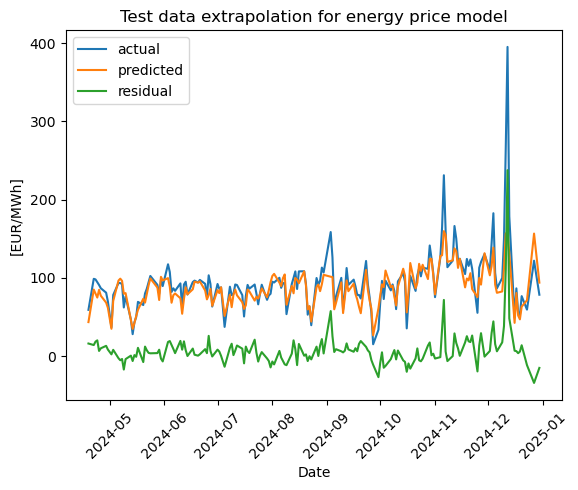

In [45]:
plt.plot(X_pr_test.index, pr_acts, label ='actual');
plt.plot(X_pr_test.index, pr_preds, label ='predicted');
plt.plot(X_pr_test.index, pr_residuals, label ='residual');
plt.legend()
plt.xticks(rotation=45);
plt.xlabel('Date')
plt.ylabel('[EUR/MWh]')
plt.title('Test data extrapolation for energy price model')
plt.show()

The R-squared of explained vs observed variance reduces from 95% on the training data to 60% on the test data, so the extrapolation to the test set is not bad, but also not great. The mean absolute error over the test period is around 13 EUR/MWh, and the mean relative error around 13%. The plot shows that the model gets the pattern mostly right, but it tends to undershoot in case of larger price spikes. Given the heteroscedasticity in parts of the residual, it might be worth exploring e.g. a weighted least squares approach instead of the ordinary least squares used here.
We also suppose that the result could be improved further by including prices for coal into the explanatory variables, and by using commoditiy prices for each calander day, rather than the business day resolution of the TTF future and the carbon index. 

<a id='residual'></a>
### Predicting the Residual Load Fraction

Our second task is to predict the residual load fraction, which enters into the price prediction. Recall that the residual load is the share of the total load that cannot be produced by renewable sources and hence needs to be provided by conventional power plants. Our approach is therefore to use as explanatory variables the total power load, as well as the meteorological variables related to productivity of renewables. As mentioned earlier, we will predict the unconstrained probit version of the residual fraction, as this is more amenable to AI methods.

In [46]:
df_residualload = df_weather[['Date','Wind_Speed', 'Sunshine_Hours', 'Temperature']]

In [47]:
df_residualload = df_residualload.join(df_consumption[['Date','Total_Load','Residual_Fraction_Probit']].set_index('Date'), on='Date', how='inner')

As observed during data preparation, there is both a seasonality and a trend in the residual load fraction. The seasonality should already be covered by the seasonality in the meteorological variables. In order to account for the trend, we explicitely add the calendar year as an explanatory variable.

In [48]:
df_residualload['Year'] =  df_residualload['Date'].dt.year
df_residualload.dropna(axis=0, inplace=True)
df_residualload.set_index('Date', inplace=True)
df_residualload.head()

,Wind_Speed,Sunshine_Hours,Temperature,Total_Load,Residual_Fraction_Probit,Year
Date,,,,,,
2015-01-01,2.7,5.4,2.2,1133468.30,0.445495,2015
2015-01-02,5.9,0.0,4.1,1334453.56,0.046027,2015
2015-01-03,4.2,0.0,3.0,1258747.92,0.232513,2015
2015-01-04,5.1,0.4,3.3,1202337.75,0.353682,2015
2015-01-05,3.3,0.3,1.5,1451660.75,0.868268,2015


The total load and the year are larger by several orders of magnitude than the other variables. We therefore rescale them in order to ensure a more stable model estimation.

In [49]:
df_residualload['Total_Load'] = df_residualload['Total_Load'] / 1e6
df_residualload['Year'] =  df_residualload['Year'] / 1e3

In [50]:
df_residualload.corr()

,Wind_Speed,Sunshine_Hours,Temperature,Total_Load,Residual_Fraction_Probit,Year
Wind_Speed,1.000000,-0.256726,-0.131434,0.198482,-0.644439,-0.039127
Sunshine_Hours,-0.256726,1.000000,0.467990,-0.295668,-0.056892,0.028479
Temperature,-0.131434,0.467990,1.000000,-0.431162,-0.155259,0.035341
Total_Load,0.198482,-0.295668,-0.431162,1.000000,0.248119,-0.202645
Residual_Fraction_Probit,-0.644439,-0.056892,-0.155259,0.248119,1.000000,-0.433956
Year,-0.039127,0.028479,0.035341,-0.202645,-0.433956,1.000000


The correlations are less pronounced than in the price case, but let us still start with splitting into training and test data and then fitting a linear regression model:

In [51]:
cols = [c for c in df_residualload.columns if c != 'Residual_Fraction_Probit']
X_rl_train, X_rl_test, y_rl_train, y_rl_test = train_test_split(df_residualload[cols], df_residualload[['Residual_Fraction_Probit']]
                                                        , test_size = 0.1, shuffle=False)

In [52]:
model = sm.OLS(y_rl_train, X_rl_train.astype(float))
results = model.fit()

In [53]:
print(results.summary2())

                            Results: Ordinary least squares
Model:                  OLS                      Adj. R-squared (uncentered): 0.804    
Dependent Variable:     Residual_Fraction_Probit AIC:                         1184.5247
Date:                   2026-05-21 19:04         BIC:                         1215.0133
No. Observations:       3287                     Log-Likelihood:              -587.26  
Df Model:               5                        F-statistic:                 2706.    
Df Residuals:           3282                     Prob (F-statistic):          0.00     
R-squared (uncentered): 0.805                    Scale:                       0.083824 
-------------------------------------------------------------------------------------------
                        Coef.      Std.Err.        t         P>|t|       [0.025      0.975]
-------------------------------------------------------------------------------------------
Wind_Speed             -0.2348       0.0036     

The R-squared of 80% is not too bad. Surprisingly, the calender year is not statistically significant in the linear model, despite the observed trend. Let us now look at the extrapolation of the model to the test data:

In [54]:
rl_lin_acts = []
rl_lin_exps = []
rl_lin_residuals = []
for i in range(len(X_rl_test.index)):
    rl_lin_exp = stats.norm.cdf((results.params.to_numpy() * X_rl_test.iloc[i]).sum())
    rl_lin_act = stats.norm.cdf(y_rl_test.iloc[i].sum())
    rl_lin_residual = rl_lin_act-rl_lin_exp
    rl_lin_acts.append(rl_lin_act)
    rl_lin_exps.append(rl_lin_exp)
    rl_lin_residuals.append(rl_lin_residual)
rl_lin_acts = np.array(rl_lin_acts)
rl_lin_exps = np.array(rl_lin_exps)
rl_lin_residual = np.array(rl_lin_residual)

In [55]:
print(f'R-squared: {r2_score(rl_lin_acts, rl_lin_exps)}')
print(f'Mean absolute error: {np.mean(np.abs(rl_lin_exps-rl_lin_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(rl_lin_exps/rl_lin_acts-1))}')

R-squared: 0.20566519070184386
Mean absolute error: 0.12229503031187218
Mean abs of relative errors base: 0.3092150493522732


The extrapolation of the linear regression is very poor, with an R-squared of only 20% and a mean relative error above 30%. We therefore consider another model that goes beyond a linear approach. Namely, we use a decision tree regression. Similar to our third capstone project, we fit decision trees to the training data along the cost-complexity pruning path, and then choose the one with the best performance on the test data.

In [56]:
decisionTreeRegressor = DecisionTreeRegressor()
path = decisionTreeRegressor.cost_complexity_pruning_path(X_rl_train, y_rl_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [57]:
regressors = []
for ccp_alpha in ccp_alphas:
    reg = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    reg.fit(X_rl_train, y_rl_train)
    regressors.append(reg)

In [58]:
train_scores = [reg.score(X_rl_train, y_rl_train) for reg in regressors]
test_scores = [reg.score(X_rl_test, y_rl_test) for reg in regressors]

The unpruned estimator tends to overfit, but tuning the pruning parameter quickly finds a model with best generalization to the test data:

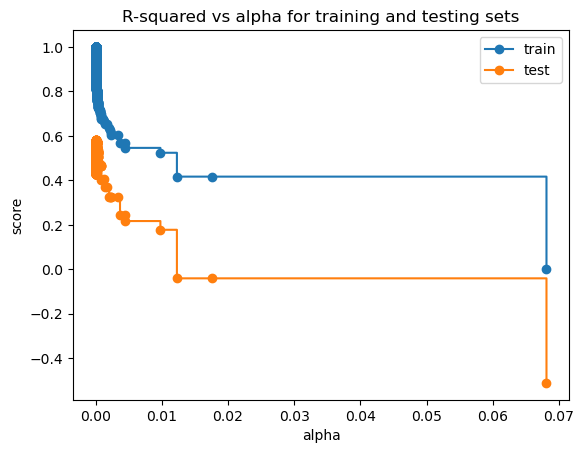

In [59]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("score")
ax.set_title("R-squared vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [60]:
best_idx = np.argmax(test_scores)
alpha_opt = ccp_alphas[best_idx]
print(f'Best alpha for pruning: {alpha_opt}')
decisionTreeRegressor = regressors[best_idx]

Best alpha for pruning: 0.0001206714629457407


In [61]:
print(f'Train score: {train_scores[best_idx]}, Test score: {test_scores[best_idx]}')

Train score: 0.8142775391954307, Test score: 0.5810860983840129


In [62]:
node_counts = [reg.tree_.node_count for reg in regressors]
depth = [reg.tree_.max_depth for reg in regressors]
print(f'Nodes: {node_counts[best_idx]}, Depth: {depth[best_idx]}')

Nodes: 231, Depth: 11


The decision tree regressor achieves an R-squared of around 80% on the training data, which is quite similar to the linear regressor. However, it extrapolates much better to the test data with an R-squared close to 60% and a mean relative error of 20%:

In [63]:
rl_dtr_acts = []
rl_dtr_exps = []
rl_dtr_residuals = []
for i in range(len(X_rl_test.index)):
    rl_dtr_exp = stats.norm.cdf(decisionTreeRegressor.predict(X_rl_test.iloc[[i]]))
    rl_dtr_act = stats.norm.cdf(y_rl_test.iloc[i])
    rl_dtr_residual = rl_dtr_act-rl_dtr_exp
    rl_dtr_acts.append(rl_dtr_act)
    rl_dtr_exps.append(rl_dtr_exp)
    rl_dtr_residuals.append(rl_dtr_residual)
rl_dtr_acts = np.array(rl_dtr_acts)
rl_dtr_exps = np.array(rl_dtr_exps)
rl_dtr_residuals = np.array(rl_dtr_residuals)

In [64]:
print(f'R-squared: {r2_score(rl_dtr_acts, rl_dtr_exps)}')
print(f'Mean absolute error: {np.mean(np.abs(rl_dtr_exps-rl_dtr_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(rl_dtr_exps/rl_dtr_acts-1))}')

R-squared: 0.5779781852700934
Mean absolute error: 0.08713976171219323
Mean abs of relative errors base: 0.2006835328620551


The decision tree's feature importances show that wind speed is the dominant driver. The total power load and the calendar year also have a certain importance, while the variables related to solar power (sunshine hours and temperature) have surprisingly little impact:

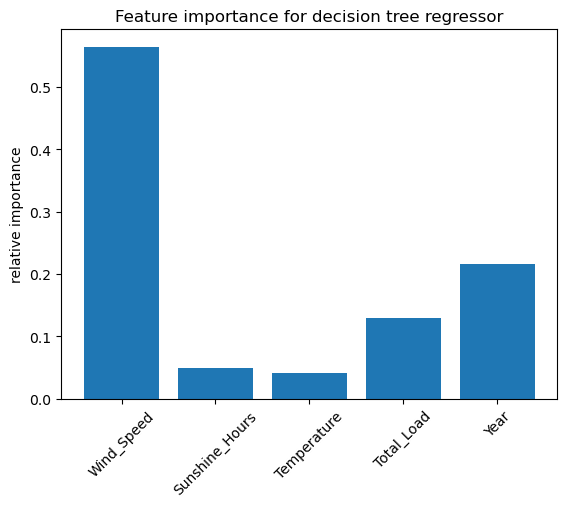

In [65]:
plt.bar(X_rl_test.columns, decisionTreeRegressor.feature_importances_);
plt.xticks(rotation=45);
plt.ylabel('relative importance')
plt.title('Feature importance for decision tree regressor')
plt.show()

The time series plots below also support the statistical observation that the decision tree does better than the linear model, but there is still quite some noise left. On the other hand, note that although Germany is not too big in surface area, weather conditions can differ quite significantly in different regions. Our approach of looking at meteorological data from a single city close to the geographical center is therefore an approximation only. Given that approximation, the predictive power of our model is actually not bad. It is quite conceivable that the model could be further improved, if one had available a breakdown into regions of both the residual load fraction and the meteorological variables. From a technical point of view, it could also be worth exploring whether the results can be further improved by extending the decision tree to ensemble-based methods (e.g random forests or boosting techniques).

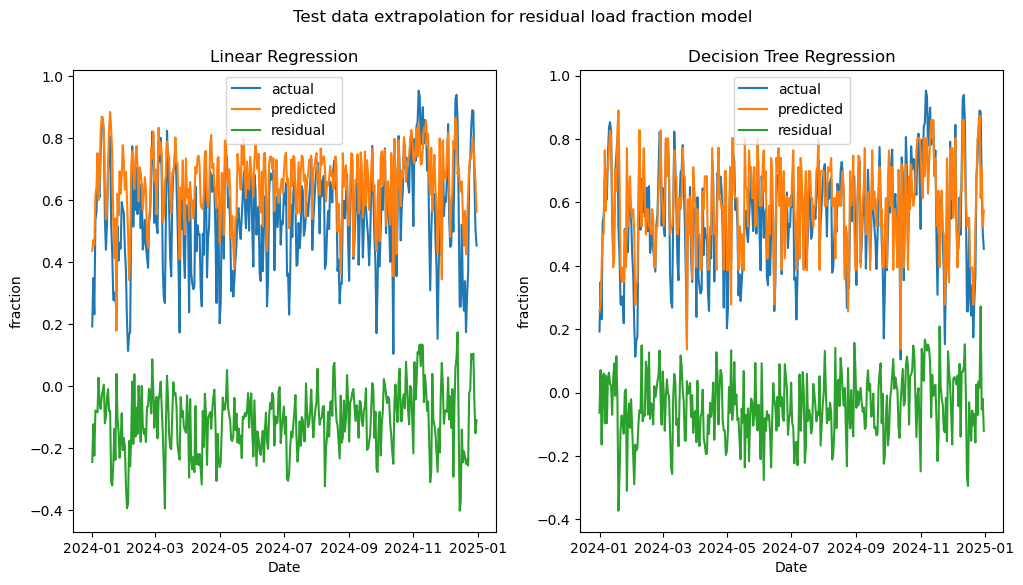

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Test data extrapolation for residual load fraction model')
ax[0].plot(X_rl_test.index, rl_lin_acts, label ='actual');
ax[0].plot(X_rl_test.index, rl_lin_exps, label ='predicted');
ax[0].plot(X_rl_test.index, rl_lin_residuals, label ='residual');
ax[1].plot(X_rl_test.index, rl_dtr_acts, label ='actual');
ax[1].plot(X_rl_test.index, rl_dtr_exps, label ='predicted');
ax[1].plot(X_rl_test.index, rl_dtr_residuals, label ='residual');
ax[0].set(xlabel='Date', ylabel='fraction', title='Linear Regression')
ax[1].set(xlabel='Date', ylabel='fraction', title='Decision Tree Regression')
ax[0].legend()
ax[1].legend()
plt.show()

<a id='total'></a>
### Forecasting the Total Load

Our third task is to build a forecasting model for the total power load, which enters the residual load fraction. The goal is to forecast the value of the total power load at time t, given a windows of predecessor values at time t-1, ..., t-n. We have studied recurrent neural networks for time series forecasting in our fourth capstone project, and we will leverage that experience now. We saw a clear seasonality when preparing the total load data, with more load in the winter than in the summer. Hence we can expect a dependence of the power load on temperature, and we thus add the temperature time series as another explanatory variable. 

In [67]:
df_totalload = df_consumption[['Date','Total_Load']].copy()
df_totalload = df_totalload.join(df_weather[['Date','Temperature']].set_index('Date'), on='Date', how='inner')

Looking at the autocorrelation function of the total power load, there is not only seasonality on an annual basis, but in addition we see a superposition of weekly seasonality patterns:

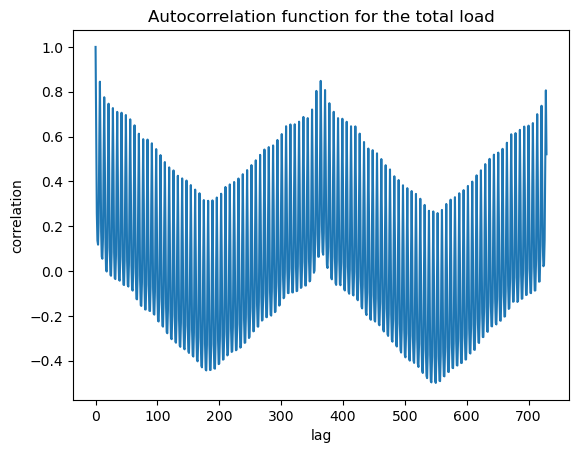

In [68]:
autocorr_tl = pd.DataFrame([[l,df_totalload.Total_Load.autocorr(lag=l)] for l in range(730)])
autocorr_tl.columns = ['lag','corr']
autocorr_tl.plot(x='lag', legend=False);
plt.ylabel('correlation')
plt.title('Autocorrelation function for the total load')
plt.show()

We therefore add the annual and weekly time information as additional explanatory variables, so that the model can learn these seasonality patterns. Also, a window size of sixty days seems like a good choice that the model can learn the patterns.

In [69]:
df_totalload['Day_Of_Year'] = df_totalload['Date'].dt.dayofyear
df_totalload['Day_Of_Week'] = df_totalload['Date'].dt.weekday
df_totalload.set_index('Date', inplace=True)
df_totalload.head()

,Total_Load,Temperature,Day_Of_Year,Day_Of_Week
Date,,,,
2015-01-01,1133468.30,2.2,1,3
2015-01-02,1334453.56,4.1,2,4
2015-01-03,1258747.92,3.0,3,5
2015-01-04,1202337.75,3.3,4,6
2015-01-05,1451660.75,1.5,5,0


In [70]:
window_size = 60

Now we split the data into a training and test set.

In [71]:
X_tl_train, X_tl_test, y_tl_train, y_tl_test = train_test_split(df_totalload, df_totalload[['Total_Load']]
                                                        , test_size = 0.1, shuffle=False)

In [72]:
X_tl_train.head()

,Total_Load,Temperature,Day_Of_Year,Day_Of_Week
Date,,,,
2015-01-01,1133468.30,2.2,1,3
2015-01-02,1334453.56,4.1,2,4
2015-01-03,1258747.92,3.0,3,5
2015-01-04,1202337.75,3.3,4,6
2015-01-05,1451660.75,1.5,5,0


Next, we define a function to split the time series into rolling windows. We also apply standard scaling, so that all features and the target variable in the training set have zero mean and unit variance.

In [73]:
def split_windows(X, y, window_size):
    '''
    A function that splits a timeseries into a series of feature windows and 
    a series of continuations of these windows with the next value
    
    Args:
        values (numpy array): The timeseries to split
        window_size (int): The length of the windows
        
    Returns:
        (numpy array, numpy array): The series of feature windows and the series of continuations                                    
    '''
    windows = []
    continuations = []
    for i in range(len(X) - window_size):
        windows.append(X[i : i + window_size])
        continuations.append(y[i + window_size])
        #fund_values.append(y[i : i + window_size])
    windows = np.array(windows, dtype=np.float32)
    continuations = np.array(continuations, dtype=np.float32)
    return (windows, continuations)

In [74]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_tl_train_scaled = scaler_X.fit_transform(X_tl_train)
y_tl_train_scaled =  scaler_y.fit_transform(y_tl_train)
X_tl_test_scaled = scaler_X.transform(X_tl_test)
y_tl_test_scaled = scaler_y.transform(y_tl_test)

In [75]:
(windows_train, values_train) = split_windows(X_tl_train_scaled, y_tl_train_scaled, window_size)
x_train_tensor = torch.tensor(windows_train)
y_train_tensor = torch.tensor(values_train).flatten(1)
(windows_test, values_test) = split_windows(X_tl_test_scaled, y_tl_test_scaled, window_size)
x_test_tensor = torch.tensor(windows_test)
y_test_tensor = torch.tensor(values_test).flatten(1)

In [76]:
print(x_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([3227, 60, 4])
torch.Size([3227, 1])


We finally need to implemented torch objects for storing and loading the data, which are required to run the model training:

In [77]:
class MyDataset(Dataset):
    '''
    A class that implements the abstract torch Dataset class.
    It wraps the data and is to be used as input for the DataLoader.
    '''
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [78]:
batch_size=64
dataset_train = MyDataset(x_train_tensor, y_train_tensor)
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_test = MyDataset(x_test_tensor, y_test_tensor)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

We now set some training parameters and implement a function for model training.

In [79]:
learn_rate = 0.001
epochs = 20
criterion = nn.MSELoss(reduction='sum')

In [80]:
def train_model(model, optimizer, criterion, loader_train, loader_test, epochs):
    '''
    A function performs the model training and logs the loss functions
    
    Args:
        model (nn.Module): The model to train
        optimizer (int): Torch optimizer used in training
        loader_train (DataLoader): Loader for batched training data
        loader_test (DataLoader): Loader for batched test data
        epochs (int): Epochs to run for training
        
    Returns:
        (array, array): The loss functions for training and test data                                    
    '''
    train_losses, test_losses = [], []
    for e in range(epochs):
        running_loss = 0
        for windows, continuations in loader_train:
            windows = windows.to(device)
            continuations = continuations.to(device)
            optimizer.zero_grad()
            predictions = model.forward(windows)
            loss = criterion(predictions, continuations)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        else:
            test_loss = 0
            with torch.no_grad():
                model.eval()
                for windows, continuations in loader_test:
                    windows = windows.to(device)
                    continuations = continuations.to(device)
                    
                    predictions = model(windows)
                    test_loss += criterion(predictions, continuations).item()
            model.train()
            
            train_losses.append(running_loss/len(loader_train))
            test_losses.append(test_loss/len(loader_test))
    
            print("Epoch: {}/{}.. ".format(e+1, epochs),
                  "Training Loss: {:.6f}.. ".format((np.sqrt(running_loss))/len(loader_train.dataset)),
                  "Test Loss: {:.6f}.. ".format((np.sqrt(test_loss))/len(loader_test.dataset))
            )
    return (train_losses, test_losses)

Next, we define and train our recurrent model using two LSTM layers and a linear layer contracting the network to feature dimension. We also use a dropout value of 0.1, such that the model doesn't overfit and generalizes better to the test data.

In [81]:
class ExtractTensor(nn.Module):
    '''
    The LSTM output has shape shape (batch, features, hidden).
    We need to remove the hidden output for further use with a linear layer in a sequential model.
    The required dimensionality reduction is implemented in this class
    '''
    def forward(self,x):
        # Output shape (batch, features, hidden)
        tensor, _ = x
        # Reshape shape (batch, hidden)
        return tensor[:, -1, :]

In [82]:
d_internal = 128
model_rnn = nn.Sequential(
    nn.LSTM(x_train_tensor.shape[2], d_internal, num_layers=2, dropout=0.1), 
    ExtractTensor(),
    nn.Linear(d_internal, y_train_tensor.shape[1])
).to(device)
optimizer = optim.Adam(model_rnn.parameters(), lr=learn_rate)

In [83]:
# Check number of trainable parameters
sum(p.numel() for p in model_rnn.parameters())

200833

In [84]:
(train_losses, test_losses) = train_model(model_rnn, optimizer, criterion, loader_train, loader_test, epochs)

Epoch: 1/20..  Training Loss: 0.015660..  Test Loss: 0.041328.. 
Epoch: 2/20..  Training Loss: 0.012566..  Test Loss: 0.041329.. 
Epoch: 3/20..  Training Loss: 0.012152..  Test Loss: 0.037133.. 
Epoch: 4/20..  Training Loss: 0.011823..  Test Loss: 0.035978.. 
Epoch: 5/20..  Training Loss: 0.011544..  Test Loss: 0.034764.. 
Epoch: 6/20..  Training Loss: 0.011187..  Test Loss: 0.034194.. 
Epoch: 7/20..  Training Loss: 0.010989..  Test Loss: 0.034366.. 
Epoch: 8/20..  Training Loss: 0.010774..  Test Loss: 0.033226.. 
Epoch: 9/20..  Training Loss: 0.010424..  Test Loss: 0.036352.. 
Epoch: 10/20..  Training Loss: 0.010093..  Test Loss: 0.031163.. 
Epoch: 11/20..  Training Loss: 0.009508..  Test Loss: 0.032049.. 
Epoch: 12/20..  Training Loss: 0.008563..  Test Loss: 0.024932.. 
Epoch: 13/20..  Training Loss: 0.007529..  Test Loss: 0.027495.. 
Epoch: 14/20..  Training Loss: 0.006767..  Test Loss: 0.022411.. 
Epoch: 15/20..  Training Loss: 0.006356..  Test Loss: 0.021491.. 
Epoch: 16/20..  Tra

We finally calculate predictions and errors on the test set.

In [85]:
tl_acts = scaler_y.inverse_transform(y_test_tensor.detach().cpu().numpy()[:,-1].flatten().reshape(-1, 1))
tl_exps = scaler_y.inverse_transform(model_rnn.forward(x_test_tensor).detach().cpu().numpy()[:,-1].flatten().reshape(-1, 1))
tl_residuals = tl_acts-tl_exps

In [86]:
metric = R2Score()
metric.update(model_rnn.forward(x_test_tensor), y_test_tensor)
metric.compute()

tensor(0.8208)

In [87]:
print(f'Mean absolute error: {np.mean(np.abs(tl_exps-tl_acts))}')
print(f'Mean abs of relative errors base: {np.mean(np.abs(tl_exps/tl_acts-1))}')

Mean absolute error: 37607.72265625
Mean abs of relative errors base: 0.030390966683626175


The model does a really good job on the test data, with an R-squared of over 80%, a mean absolute error of around 38k MWh, and a mean relative error of only 3%. This is also confirmed in the visualization of the time series below:

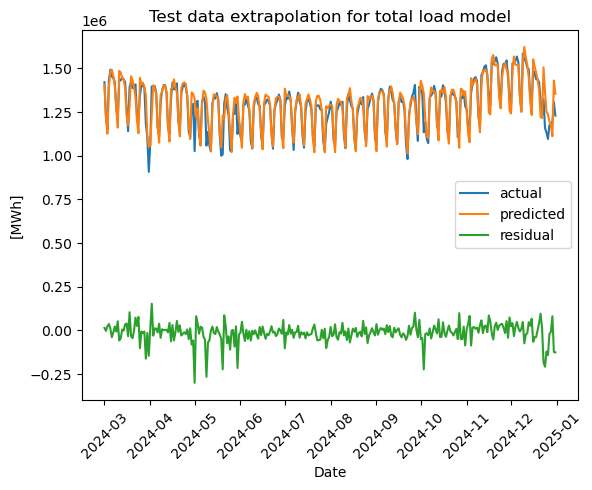

In [88]:
plt.plot(X_tl_test.index[window_size:], tl_acts, label ='actual');
plt.plot(X_tl_test.index[window_size:], tl_exps, label ='predicted');
plt.plot(X_tl_test.index[window_size:], tl_residuals, label ='residual');
plt.legend()
plt.xticks(rotation=45);
plt.xlabel('Date')
plt.ylabel('[MWh]')
plt.title('Test data extrapolation for total load model')
plt.show()

We finally look at the loss curves for training and test set. This reveals an interesting pattern: The model starts learning fast in the first two epochs, then slows down until around epoch ten before making another leap between epoch ten and fifteen. After 20 epochs, we see that training has converged:

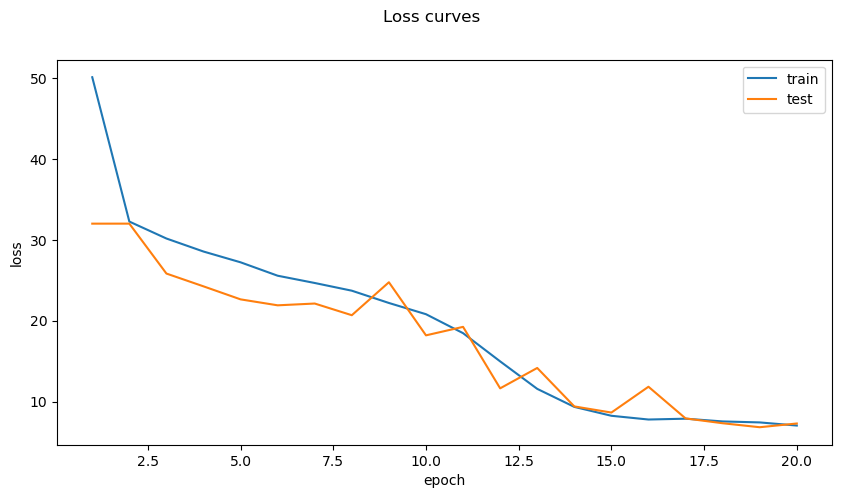

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Loss curves')
ax.plot(range(1,epochs+1), train_losses, label="train")
ax.plot(range(1,epochs+1), test_losses, label="test")
ax.set(xlabel='epoch', ylabel='loss')
ax.legend(loc="upper right")
plt.show()

<a id='flows'></a>
### Workflows and Use Cases

In this section, we present several workflows and potential use cases for the building block models introduced in the previous sections.

The first workflow uses the total load RNN model to forecast the total load at time t, given values of total load and temperature until time t-1:

```mermaid
flowchart LR
A("TotalLoad(t-n,...,t-1), Temperature(t-n,...,t-1)")-->B["Total Load Model"]
B-->C("TotalLoad(t)")
```

A possible use case of that workflow is for regulartors or power grid administrators to forecast the total load for steering or management purposes.

The first inflow integrates into the second workflow, where the total load forecast is joint in the residual load decision tree model with meteorological forecasts (wind speed, temperature, sunshine hours), in order to predict the residual load at time t:

```mermaid
flowchart LR
subgraph s1["Workflow 1"]
A("TotalLoad(t-n,...,t-1), Temperature(t-n,...,t-1)")-->B["Total Load Model"]
B-->C("TotalLoad(t)")
end
C-->D["Residual Load Model"]
E("MeteorologicalForecast(t)")-->D
D-->F("ResidualLoad(t)")
```

This workflow could e.g. be used by the grid administrator and by operators of conventional power plants to predict the power that needs to be produced beyond renewable sources at time t in order to meet the energy demand.

The second workflow integrates into the third workflow, where the residual load prediction is joint in the energy price linear regression model with an assumption or forecast for the commodity prices (natural gas, carbon allowances and potentially coal), in order to predict the energy price at time t:

```mermaid
flowchart LR
subgraph s1["Workflow 2"]
A("TotalLoad(t-n,...,t-1), Temperature(t-n,...,t-1)")-->B["Total Load Model"]
B-->C("TotalLoad(t)")
C-->D["Residual Load Model"]
E("MeteorologicalForecast(t)")-->D
D-->F("ResidualLoad(t)")
end
F-->G["Energy Price Model"]
H("CommodityPriceAssumption(t)")-->G
G-->I("EnergyPrice(t)")
```

This workflow could e.g. be used by industrial companies with large energy demand to hedge against energy price movements by calculating the sensitivity of the energy price with respect to the commodity prices. It could also be used by financial firms such as hedge funds for speculation or for detecting arbitrage in commodity futures versus outright power futures. 

<a id='lim'></a>
### Limitations and Future Improvements
In this section, we summarize some limitations of and potential improvements for our system, that have already been mentioned in the individual sections for the most part.

- The linear regression model for the energy price is limited by missing data for coal prices. This could be improved by purchasing data licenses to include them into the model. Another limitation is that there is some heteroscedasticity in the residuals, which affects the statistical estimation of the model. This could be improved by using e.g. weighted least squares instead of ordinary least squares.
- The decision tree model for the residual load has the limitation that the meterological exaplanatory variables are only used for a single location within Germany. The model could likely be improved by considering a more granular resolution of both meteorological and residual load data into regions. It could also be explored whether the model can be improved by extending from a decision tree regressor to ensemble-based methods such as random forests.
- The recurrent neural network model for the total load performs quite good already. One could explore whether extending its architecture to more LSTM layers or a higher-dimensional embedding has the potential of reducing the mean errors on the test set even below the current levels.
- If one considers using the workflows for productive purposes, then the point of regularly re-calibrating the models needs to be considered. Future research could address the best frequencies and triggers for these updates. One would also need to establish a regular model review process in order to decide whether the models are still appropriate given the market environment.

<a id='summary'></a>
### Summary

In this integrative project, we delved into the German energy market. We imported several datasets covering physical aspects of supply and demand in the power grid, meteorological aspects that drive the renewables part of the supply, as well as financial aspects that are relevant for the formation of wholesale energy prices. Then we developed, trained and evaluated three building block models: A linear regression model for predicting the energy price, a decision tree regression model for predicting the residual load, and a recurrent neural network for forecasting the total load timeseries. These building block models were then integrated into a system of workflows that could add value for regulators, suppliers, wholesale customers, or financial companies. We also identified limitations of the system as well as areas of potential future improvements. As a final reminder, it goes without saying that the output of prediction and forecasting models must not be taken for granted, but should rather be assessed in statistical terms.

In [90]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt